In [2]:
pip install python-dotenv

Note: you may need to restart the kernel to use updated packages.


In [4]:
import os
from dotenv import load_dotenv
load_dotenv(r'C:\Users\james\projects\dj\src\backend\.env')
SPOTIPY_CLIENT_ID = os.getenv("SPOTIPY_CLIENT_ID")
SPOTIPY_CLIENT_SECRET = os.getenv("SPOTIPY_CLIENT_SECRET")
SPOTIPY_REDIRECT_URI= os.getenv("SPOTIPY_REDIRECT_URI")

In [9]:
import librosa 
filename = librosa.example('nutcracker')

#load the audio as a waveform y 
#store the sampling rate as sr 

y,sr = librosa.load(filename)
tempo,beat_frames = librosa.beat.beat_track(y=y,sr=sr)

print(f'Estimated tempo:{tempo} beats per minute')
#convert the frame indicies of beat events into timestamps 
beat_times = librosa.frames_to_time(beat_frames, sr=sr)

Estimated tempo:[107.66601562] beats per minute


By default, all audio is mixed to mono and resampled to 22050 Hz
This can be orveridden by passing additional arguments to librosa.load 

In [10]:
beat_times

array([  1.18421769,   1.71827664,   2.32199546,   2.87927438,
         3.45977324,   4.01705215,   4.59755102,   5.13160998,
         5.7353288 ,   6.29260771,   6.84988662,   7.40716553,
         7.9876644 ,   8.54494331,   9.12544218,   9.65950113,
        10.21678005,  10.72761905,  11.28489796,  11.79573696,
        12.32979592,  12.86385488,  13.42113379,  13.95519274,
        14.4892517 ,  15.02331066,  15.55736961,  16.09142857,
        16.62548753,  17.15954649,  17.69360544,  18.25088435,
        18.80816327,  19.31900227,  19.87628118,  20.38712018,
        20.92117914,  21.4552381 ,  21.98929705,  22.52335601,
        23.05741497,  23.59147392,  24.12553288,  24.65959184,
        25.19365079,  25.72770975,  26.26176871,  26.81904762,
        27.35310658,  27.88716553,  28.44444444,  29.00172336,
        29.55900227,  30.11628118,  30.67356009,  31.20761905,
        31.78811791,  32.34539683,  32.85623583,  33.36707483,
        33.90113379,  34.43519274,  34.94603175,  35.48

In [11]:
# Feature extraction example
import numpy as np
import librosa

# Load the example clip
y, sr = librosa.load(librosa.ex('nutcracker'))

# Set the hop length; at 22050 Hz, 512 samples ~= 23ms
hop_length = 512

# Separate harmonics and percussives into two waveforms
y_harmonic, y_percussive = librosa.effects.hpss(y)

# Beat track on the percussive signal
tempo, beat_frames = librosa.beat.beat_track(y=y_percussive,
                                             sr=sr)

# Compute MFCC features from the raw signal
mfcc = librosa.feature.mfcc(y=y, sr=sr, hop_length=hop_length, n_mfcc=13)

# And the first-order differences (delta features)
mfcc_delta = librosa.feature.delta(mfcc)

# Stack and synchronize between beat events
# This time, we'll use the mean value (default) instead of median
beat_mfcc_delta = librosa.util.sync(np.vstack([mfcc, mfcc_delta]),
                                    beat_frames)

# Compute chroma features from the harmonic signal
chromagram = librosa.feature.chroma_cqt(y=y_harmonic,
                                        sr=sr)

# Aggregate chroma features between beat events
# We'll use the median value of each feature between beat frames
beat_chroma = librosa.util.sync(chromagram,
                                beat_frames,
                                aggregate=np.median)

# Finally, stack all beat-synchronous features together
beat_features = np.vstack([beat_chroma, beat_mfcc_delta])

In [12]:
chromagram

array([[0.39618528, 0.72629374, 0.5060056 , ..., 0.07622113, 0.18201338,
        0.21932504],
       [0.17634657, 0.23559262, 0.20883857, ..., 0.14753209, 0.12595648,
        0.12242372],
       [0.254989  , 0.47872236, 0.32692438, ..., 0.50170094, 0.38009268,
        0.33189562],
       ...,
       [0.4249149 , 1.        , 0.3695033 , ..., 0.08518405, 0.11850842,
        0.1894245 ],
       [0.53036946, 0.75995296, 0.5105535 , ..., 0.24618667, 0.19867043,
        0.24939644],
       [1.        , 0.9257721 , 1.        , ..., 0.9749105 , 0.87543726,
        1.        ]], shape=(12, 5163), dtype=float32)

In [ ]:
#Testing Stuff 

In [ ]:
#loading a file from mp3
filename = 'test_file.mp3'
y,sr = librosa.load(filename)

array([-4.2989970e-05, -7.7635865e-05, -6.0207178e-05, ...,
        6.2392304e-05,  6.8030255e-05,  8.1143429e-05],
      shape=(4784850,), dtype=float32)

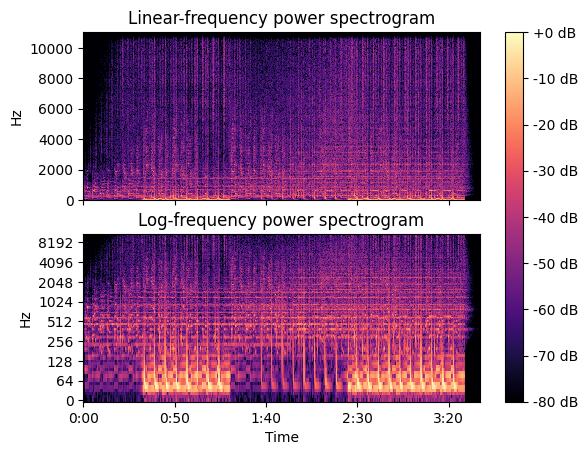

In [19]:
import matplotlib.pyplot as plt
y, sr = librosa.load(filename)
fig, ax = plt.subplots(nrows=2, ncols=1, sharex=True)
D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
img = librosa.display.specshow(D, y_axis='linear', x_axis='time',
                               sr=sr, ax=ax[0])
ax[0].set(title='Linear-frequency power spectrogram')
ax[0].label_outer()

hop_length = 1024
D = librosa.amplitude_to_db(np.abs(librosa.stft(y, hop_length=hop_length)),
                            ref=np.max)
librosa.display.specshow(D, y_axis='log', sr=sr, hop_length=hop_length,
                         x_axis='time', ax=ax[1])
ax[1].set(title='Log-frequency power spectrogram')
ax[1].label_outer()
fig.colorbar(img, ax=ax, format="%+2.f dB")

c:\Users\james\AppData\Local\Programs\Python\Python310\lib\site-packages\librosa\feature\spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)


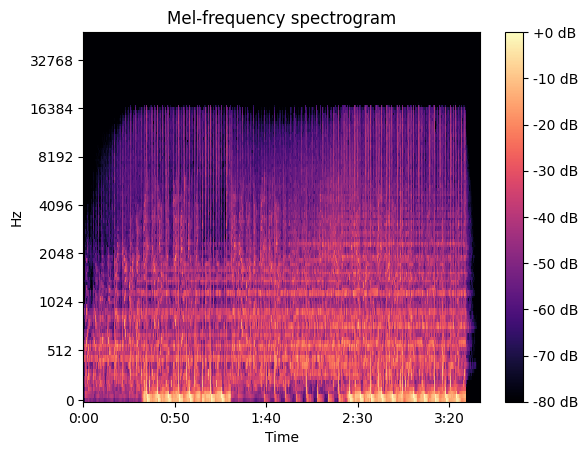

In [46]:
#Melspectogram
y, sr = librosa.load(filename, sr=None)
S = librosa.feature.melspectrogram(y=y, sr=sr,fmax = sr) 
#S has an optional parameter of fmax, which is the highest frequency 11025
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
S_dB = librosa.power_to_db(S, ref=np.max)
img = librosa.display.specshow(S_dB, x_axis='time',
                         y_axis='mel', sr=sr,
                         fmax=sr, ax=ax)
fig.colorbar(img, ax=ax, format='%+2.0f dB')
ax.set(title='Mel-frequency spectrogram')
plt.show()

#can see the ccut off around 16000

In [2]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

y, sr = librosa.load(filename)

S = librosa.feature.melspectrogram(y=y, sr=sr)
S_db = librosa.power_to_db(S, ref=np.max)

mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)

fig, ax = plt.subplots(nrows=2, sharex=True)

img = librosa.display.specshow(S_db,
                               x_axis='time',
                               y_axis='mel',
                               sr=sr,
                               ax=ax[0])
fig.colorbar(img, ax=ax[0])
ax[0].set(title='Mel spectrogram')
ax[0].label_outer()

img = librosa.display.specshow(mfccs,
                               x_axis='time',
                               sr=sr,
                               ax=ax[1])
fig.colorbar(img, ax=ax[1])
ax[1].set(title='MFCC')

plt.show()

NameError: name 'filename' is not defined

In [62]:
#Tempo 
filename = 'test_file.mp3'
y,sr = librosa.load(filename)
tempo,beat_frames = librosa.beat.beat_track(y=y,sr=sr)

In [63]:
tempo

array([117.45383523])

In [61]:
# Estimate a static tempo
y, sr = librosa.load(filename)
onset_env = librosa.onset.onset_strength(y=y, sr=sr)
tempo2 = librosa.feature.tempo(onset_envelope=onset_env, sr=sr)
tempo2

array([117.45383523])

In [64]:
# Or a dynamic tempo
dtempo = librosa.feature.tempo(onset_envelope=onset_env, sr=sr,
                               aggregate=None)
dtempo

array([123.046875  , 123.046875  , 123.046875  , ..., 129.19921875,
       129.19921875, 129.19921875], shape=(9346,))

In [3]:
track_1 = 'test_file.mp3'
track_2 = 'test_file_2.mp3'
y_ref, sr = librosa.load(track_1)
y_comp, sr = librosa.load(track_2)
chroma_ref = librosa.feature.mfcc(y=y_ref, sr=sr)
chroma_comp = librosa.feature.mfcc(y=y_comp, sr=sr)

x_ref = librosa.feature.stack_memory(chroma_ref, n_steps=10, delay=3)
x_comp = librosa.feature.stack_memory(chroma_comp, n_steps=10, delay=3)

xsim = librosa.segment.cross_similarity(x_comp, x_ref, metric = 'cosine')
xsim_aff = librosa.segment.cross_similarity(x_comp, x_ref, metric='cosine', mode='affinity')

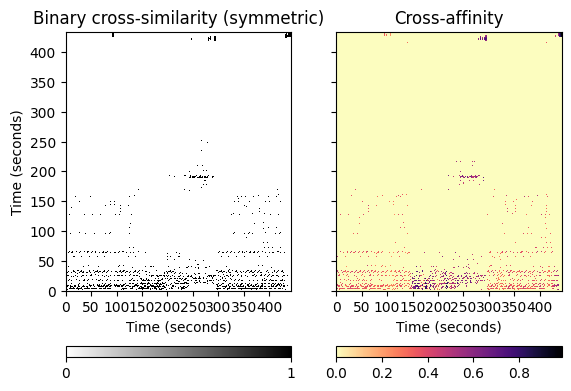

In [5]:
import matplotlib.pyplot as plt
hop_length = 1024
fig, ax = plt.subplots(ncols=2, sharex=True, sharey=True)
imgsim = librosa.display.specshow(xsim, x_axis='s', y_axis='s',
                         hop_length=hop_length, ax=ax[0])
ax[0].set(title='Binary cross-similarity (symmetric)')
imgaff = librosa.display.specshow(xsim_aff, x_axis='s', y_axis='s',
                         cmap='magma_r', hop_length=hop_length, ax=ax[1])
ax[1].set(title='Cross-affinity')
ax[1].label_outer()
fig.colorbar(imgsim, ax=ax[0], orientation='horizontal', ticks=[0, 1])
fig.colorbar(imgaff, ax=ax[1], orientation='horizontal')